# B104 Artificial Intelligence & Machine Learning
## Final Project: Predicting Bank Term Deposits
**Divakar Sabarwal | Gisma University of Applied Sciences**

### 1. Business problem and data
Can customer records and prior-campaign history identify likely term-deposit subscribers before campaign planning? Telephone marketing costs staff time; a campaign manager could prioritise eligible customers to improve response per contact. This is **binary classification**: `yes=1` (subscribed), `no=0`.

The local `data/dataset.csv` is UCI **bank-additional-full.csv**: 41,188 records, 20 inputs and target `y`, date-ordered from May 2008 to November 2010 (Moro, Rita and Cortez, 2014). Source: https://doi.org/10.24432/C5K306. Equivalent inputs could come from customer records and campaign logs.

These are historical outcomes among contacted customers, not evidence that calling causes subscriptions. A record is a campaign outcome, not a verified unique customer; no customer ID is available. The workflow follows the lecture's end-to-end process (Mahdavi, n.d.a).

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay)

print("Python", sys.version.split()[0], "| pandas", pd.__version__,
      "| NumPy", np.__version__, "| scikit-learn", sklearn.__version__)
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
df = pd.read_csv("data/dataset.csv", sep=";")
print("Raw shape:", df.shape, "| Missing cells:", df.isna().sum().sum())
print("Exact duplicates:", df.duplicated().sum())
display(df.head(3))
df = df.drop_duplicates(keep="first").copy()
print("Cleaned shape:", df.shape)

Python 3.9.6 | pandas 2.3.3 | NumPy 2.0.2 | scikit-learn 1.6.1
Raw shape: (41188, 21) | Missing cells: 0
Exact duplicates: 12


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


Cleaned shape: (41176, 21)


### 2. Data separation and prediction-time information
Remove 12 exact duplicates before splitting, preserving first occurrences and order. Identical records cannot be proven to represent the same person.

Reserve the existing latest **20% for testing**. Divide the earlier 80% into **75% fitting / 25% validation**: approximately **60/20/20 overall**. Date-ordered holdout follows Mahdavi (n.d.b, p.5; n.d.e, pp.29-32). Full dates and customer IDs are absent, limiting checks for repeated customers and calendar boundaries.

Preliminary EDA examined all development data (fitting plus validation); validation is therefore selection evidence, not fully blind assessment. EDA below keeps that labelled scope. No model choice uses test outcomes.

In [2]:
development, test = train_test_split(df, test_size=0.20, shuffle=False)
training, validation = train_test_split(development, test_size=0.25, shuffle=False)
print("Fitting:", len(training), "Validation:", len(validation), "Test:", len(test))
display(pd.DataFrame({
    "records": [len(training), len(validation)],
    "subscribers": [training["y"].eq("yes").sum(), validation["y"].eq("yes").sum()]
}, index=["Fitting", "Validation"]))
assert set(development.index).isdisjoint(test.index)
assert set(training.index).isdisjoint(validation.index)

Fitting: 24705 Validation: 8235 Test: 8236


,records,subscribers
Fitting,24705,1188
Validation,8235,912


| Fields | Decision at campaign planning |
|---|---|
| Age, job, marital, education, default, housing, loan | Retain; assume customer details are available |
| `previous`, `pdays`, `poutcome` | Retain; assume prior-campaign history is recorded |
| `duration` | Exclude: available only after the call |
| `campaign`, `contact`, `month`, `day_of_week` | Exclude: retrospective current-campaign/last-contact fields |
| Five economic indicators | Exclude: release-time availability cannot be verified |

This sacrifices predictive information for clearer timing. Historical snapshots of retained fields also require verification before deployment (Mahdavi, n.d.b, pp.40-41).

### 3. Exploratory data analysis (development only)
EDA means examining distributions, missing information and relationships before choosing transformations and models.

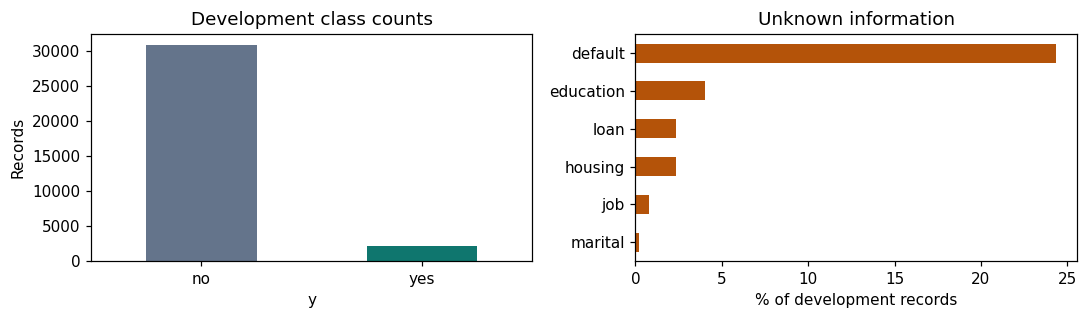

Subscriber rate: 6.38%; always-no accuracy: 93.62%


,unknown (%)
marital,0.19
job,0.81
housing,2.37
loan,2.37
education,4.01
default,24.34


,age,previous,pdays
count,32940.0,32940.0,174.0
min,18.0,0.0,0.0
50%,39.0,0.0,5.0
max,95.0,3.0,12.0


In [3]:
eda = development.copy()
eda["subscribed"] = eda["y"].eq("yes").astype(int)
base_rate = eda["subscribed"].mean()
counts = eda["y"].value_counts().reindex(["no", "yes"])
unknown = eda.select_dtypes("object").eq("unknown").mean().mul(100)
unknown = unknown[unknown > 0].sort_values()
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
counts.plot.bar(ax=axes[0], rot=0, color=["#64748b", "#0f766e"])
axes[0].set(title="Development class counts", ylabel="Records")
unknown.plot.barh(ax=axes[1], color="#b45309")
axes[1].set(title="Unknown information", xlabel="% of development records")
plt.tight_layout()
plt.show()
print(f"Subscriber rate: {base_rate:.2%}; always-no accuracy: {1-base_rate:.2%}")
display(unknown.round(2).rename("unknown (%)").to_frame())
numeric_summary = eda[["age", "previous", "pdays"]].copy()
numeric_summary["pdays"] = numeric_summary["pdays"].replace(999, np.nan)
display(numeric_summary.describe().loc[["count", "min", "50%", "max"]].round(1))

There are **2,100 subscribers (6.38%)** in development data. Always predicting `no` gives **93.62% accuracy** but zero subscriber recall. Accuracy alone is unsuitable for selection (Mahdavi, n.d.b, p.11).

Ordinary nulls are absent, but `default` is **24.34% unknown**. Keep unknown as a category rather than equating it to `no` or deleting many records. Ages **18-95** are not automatically errors; retain plausible extremes. Only **174** records have valid `pdays` intervals (**0-12 days**); `999` represents no previous contact, not a measured interval. This needs a separate indicator.

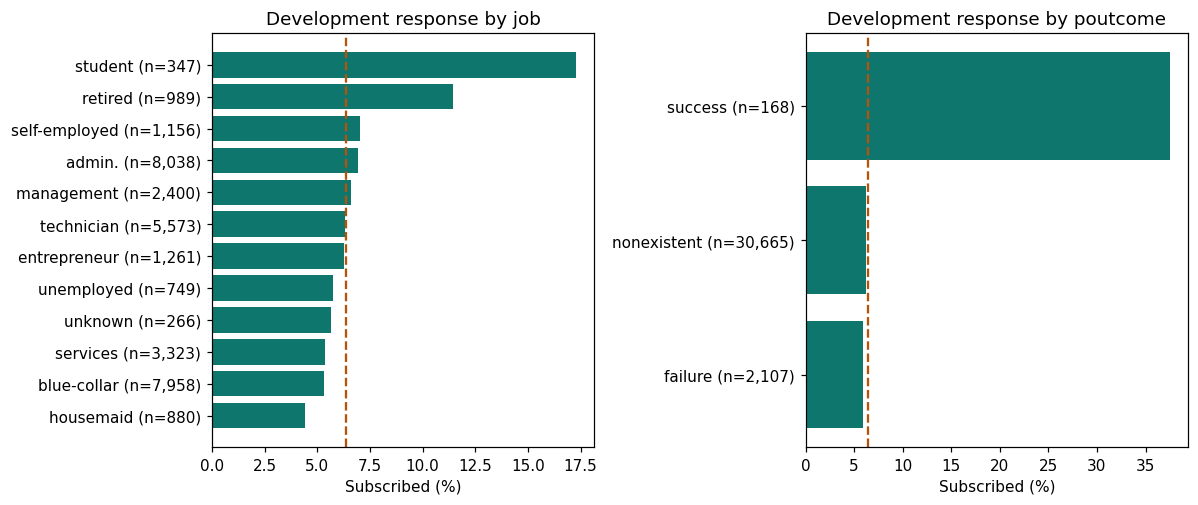

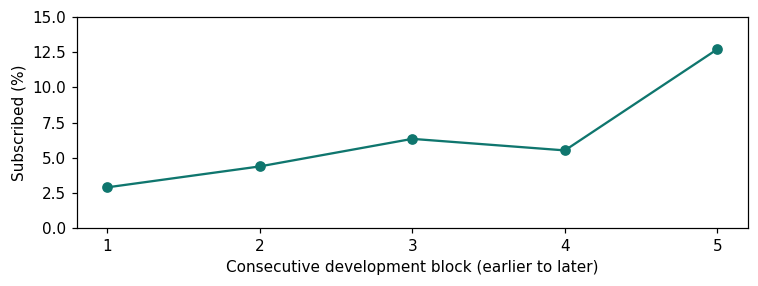

Block rates (%): [ 2.9   4.39  6.34  5.53 12.72]


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.7))
for ax, col in zip(axes, ["job", "poutcome"]):
    rates = eda.groupby(col)["subscribed"].agg(["size", "mean"]).sort_values("mean")
    labels = [f"{name} (n={n:,})" for name, n in rates["size"].items()]
    ax.barh(labels, rates["mean"] * 100, color="#0f766e")
    ax.axvline(base_rate * 100, color="#b45309", linestyle="--")
    ax.set(title=f"Development response by {col}", xlabel="Subscribed (%)")
plt.tight_layout()
plt.show()
blocks = np.array_split(np.arange(len(eda)), 5)
block_rates = [eda.iloc[b]["subscribed"].mean() * 100 for b in blocks]
plt.figure(figsize=(7, 2.7))
plt.plot(range(1, 6), block_rates, "o-", color="#0f766e")
plt.xticks(range(1, 6))
plt.xlabel("Consecutive development block (earlier to later)")
plt.ylabel("Subscribed (%)")
plt.ylim(0, 15)
plt.tight_layout()
plt.show()
print("Block rates (%):", np.round(block_rates, 2))

Students show **17.29%** response (`n=347`) and retired customers **11.43%** (`n=989`). Prior success shows **37.50%**, but only **168 records** support that estimate. These associations can reflect customer selection and time; they are not causal targeting rules.

Equal-sized development blocks range from **2.90% to 12.72%** response. This supports chronological validation and cautions against assuming a stable population. Blocks are not equal calendar periods. Only **six** non-sentinel `pdays` records occur in the earlier fitting subset, making initial estimates for prior-contact history especially uncertain.

### 4. Preprocessing and feature engineering
Create `previously_contacted`; replace `pdays=999` with zero. The flag distinguishes no previous contact from a real zero-day interval. These fixed rules learn no statistics.

Standardise numeric inputs for logistic regularisation and KNN distances. One-hot encode categories, including `unknown`, and omit one reference per field for coefficient interpretation. This choice also affects KNN distances. The binary flag passes through unchanged. No ordinary numeric values require imputation (Mahdavi, n.d.b, pp.19-27; scikit-learn developers, n.d.d).

`ColumnTransformer` applies these steps by column type. `Pipeline` combines them with a classifier: transformations learn from fitting data during selection and development data during final refitting, never from test data (scikit-learn developers, n.d.a).

In [5]:
features = ["age", "job", "marital", "education", "default", "housing", "loan",
            "pdays", "previous", "poutcome"]
numeric = ["age", "pdays", "previous"]
categorical = ["job", "marital", "education", "default", "housing", "loan", "poutcome"]

def prepare_features(data):
    X = data[features].copy()
    X["previously_contacted"] = X["pdays"].ne(999).astype(int)
    X["pdays"] = X["pdays"].replace(999, 0)
    return X

def make_model(classifier):
    preprocessing = ColumnTransformer([
        ("numeric", StandardScaler(), numeric),
        ("category", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical),
        ("flag", "passthrough", ["previously_contacted"])
    ])
    return Pipeline([("prepare", preprocessing), ("model", classifier)])

X_train = prepare_features(training)
X_valid = prepare_features(validation)
y_train = training["y"].map({"no": 0, "yes": 1})
y_valid = validation["y"].map({"no": 0, "yes": 1})

### 5. Model comparison and hyperparameter tuning
**Logistic regression** provides a regularised classifier with interpretable weights (Mahdavi, n.d.c). **KNN** tests similarity between profiles, but distances, dimensionality and prediction cost can limit it (Mahdavi, n.d.d; scikit-learn developers, n.d.c). Baselines predict everyone `no` or everyone `yes`.

Select by **subscriber F1**, balancing precision (response among flagged customers) and recall (subscribers captured). False positives waste contacts; false negatives miss opportunities. Without monetary costs, F1 is a compromise, not profit. Report ROC-AUC and accuracy too. Fix the threshold at **0.5** before selection (Mahdavi, n.d.e, pp.42-57).

Manual grid: logistic `C = 0.1, 1, 10`, with/without balanced class weights; KNN `k = 5, 15, 25, 51`, uniform votes and Euclidean distance. Smaller `C` strengthens regularisation; larger `k` smooths decisions. Compare weighting empirically instead of automatically resampling. All ten learned candidates and two baselines use the same validation records; exact F1 ties retain listed order. This is a limited search (Mahdavi, n.d.e, pp.22-25; scikit-learn developers, n.d.b).

In [6]:
def evaluate(labels, probabilities):
    predictions = (probabilities >= 0.5).astype(int)
    return {"Accuracy": accuracy_score(labels, predictions),
            "Precision": precision_score(labels, predictions, zero_division=0),
            "Recall": recall_score(labels, predictions, zero_division=0),
            "F1": f1_score(labels, predictions, zero_division=0),
            "ROC-AUC": roc_auc_score(labels, probabilities)}

candidates = {
    "Always no": DummyClassifier(strategy="constant", constant=0),
    "Always yes": DummyClassifier(strategy="constant", constant=1)
}
for C in [0.1, 1, 10]:
    for weight in [None, "balanced"]:
        name = f"Logistic C={C}, weight={weight}"
        candidates[name] = LogisticRegression(C=C, class_weight=weight, max_iter=1000)
for k in [5, 15, 25, 51]:
    candidates[f"KNN k={k}"] = KNeighborsClassifier(n_neighbors=k)

fitted = {}
rows = []
for name, classifier in candidates.items():
    model = make_model(classifier)
    model.fit(X_train, y_train)
    probability = model.predict_proba(X_valid)[:, 1]
    rows.append({"Model": name, **evaluate(y_valid, probability)})
    fitted[name] = model
results = pd.DataFrame(rows).set_index("Model")
results = results.sort_values("F1", ascending=False, kind="stable")
display(results.round(4))
best_name = results.index[0]
selected = fitted[best_name]
fit_scores = evaluate(y_train, selected.predict_proba(X_train)[:, 1])
display(pd.DataFrame([fit_scores, results.loc[best_name].to_dict()],
                     index=["Fitting", "Validation"]).round(4))
print("Selected before test evaluation:", best_name)

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
"Logistic C=0.1, weight=balanced",0.5246,0.1391,0.6349,0.2283,0.6071
"Logistic C=1, weight=balanced",0.5237,0.1389,0.6349,0.2280,0.6046
"Logistic C=10, weight=balanced",0.5241,0.1387,0.6327,0.2275,0.6044
Always yes,0.1107,0.1107,1.0000,0.1994,0.5000
"Logistic C=0.1, weight=None",0.8877,0.3243,0.0132,0.0253,0.6114
"Logistic C=1, weight=None",0.8876,0.3056,0.0121,0.0232,0.6028
"Logistic C=10, weight=None",0.8876,0.3056,0.0121,0.0232,0.6009
Always no,0.8893,0.0000,0.0000,0.0000,0.5000
KNN k=5,0.8885,0.0000,0.0000,0.0000,0.5117


,Accuracy,Precision,Recall,F1,ROC-AUC
Fitting,0.4814,0.0542,0.5943,0.0993,0.5533
Validation,0.5246,0.1391,0.6349,0.2283,0.6071


Selected before test evaluation: Logistic C=0.1, weight=balanced


**Selection:** balanced logistic regression with **C=0.1** has the highest validation F1 (**0.2283**); precision is **0.1391**, recall **0.6349**. Unweighted C=0.1 has F1 **0.0253**, despite slightly higher ROC-AUC. Weighting improves the chosen precision/recall trade-off, not every metric. KNN captures no true positives at this threshold. Balanced C values are nearly tied, so the exact optimum is uncertain. Fitting F1 is **0.0993**: differing class proportions/periods prevent a simple overfitting diagnosis. One holdout and a small search limit reliability.

### 6. Final evaluation on the reserved test set
Refit the selected pipeline on all **32,940 development rows**, then evaluate **8,236 later test records**. Features, model settings and threshold are fixed; no further tuning follows. Undefined precision with no predicted positives is displayed as zero (Mahdavi, n.d.e, p.31).

,Accuracy,Precision,Recall,F1,ROC-AUC
"Logistic C=0.1, weight=balanced",0.5200,0.3682,0.7779,0.4998,0.6837
Always no,0.6917,0.0000,0.0000,0.0000,0.5000
Always yes,0.3083,0.3083,1.0000,0.4713,0.5000


Test subscriber rate: 30.83%


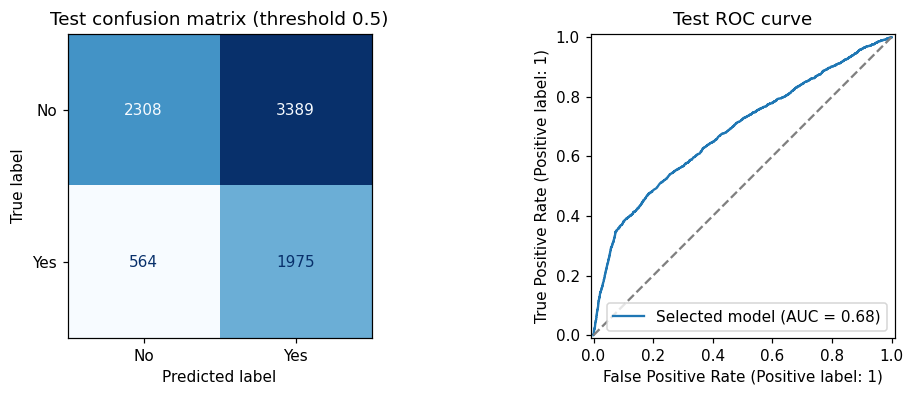

Flagged: 5,364; subscribers captured: 1,975; non-subscribers flagged: 3,389; subscribers missed: 564


In [7]:
X_dev = prepare_features(development)
y_dev = development["y"].map({"no": 0, "yes": 1})
final_model = selected
final_model.fit(X_dev, y_dev)
X_test = prepare_features(test)
y_test = test["y"].map({"no": 0, "yes": 1})
test_probability = final_model.predict_proba(X_test)[:, 1]
test_prediction = (test_probability >= 0.5).astype(int)
test_scores = evaluate(y_test, test_probability)
test_results = pd.DataFrame([
    test_scores,
    evaluate(y_test, np.zeros(len(y_test))),
    evaluate(y_test, np.ones(len(y_test)))
], index=[best_name, "Always no", "Always yes"])
display(test_results.round(4))
print(f"Test subscriber rate: {y_test.mean():.2%}")
assert np.isfinite(test_probability).all()

fig, axes = plt.subplots(1, 2, figsize=(10, 3.7))
ConfusionMatrixDisplay.from_predictions(y_test, test_prediction, ax=axes[0],
    display_labels=["No", "Yes"], colorbar=False, cmap="Blues")
axes[0].set_title("Test confusion matrix (threshold 0.5)")
RocCurveDisplay.from_predictions(y_test, test_probability, ax=axes[1], name="Selected model")
axes[1].plot([0, 1], [0, 1], "--", color="grey")
axes[1].set_title("Test ROC curve")
plt.tight_layout()
plt.show()
tn, fp, fn, tp = confusion_matrix(y_test, test_prediction).ravel()
print(f"Flagged: {tp+fp:,}; subscribers captured: {tp:,}; "
      f"non-subscribers flagged: {fp:,}; subscribers missed: {fn:,}")

Test F1 is **0.4998**, precision **0.3682**, recall **0.7779**, and ROC-AUC **0.6837**. Accuracy (**0.5200**) is below the always-no baseline, which captures no subscribers. Always-yes F1 is already **0.4713**, so the model's F1 advantage is modest. Positive rates change from **4.81% fitting** to **11.07% validation** and **30.83% test**. Higher test F1 does not prove greater stability: prevalence changed and refitting added later observations.

### 7. Explainability
Positive logistic coefficients raise the model score; negative ones lower it. Numeric coefficients describe a development standard-deviation change after refitting. Categorical coefficients compare with omitted references; the history flag changes from 0 to 1.

The ten largest absolute coefficients describe model associations, not causal effects or a definitive importance ranking. Their units differ; rare categories and overlapping history fields can make them unstable (Mahdavi, n.d.c, p.3).

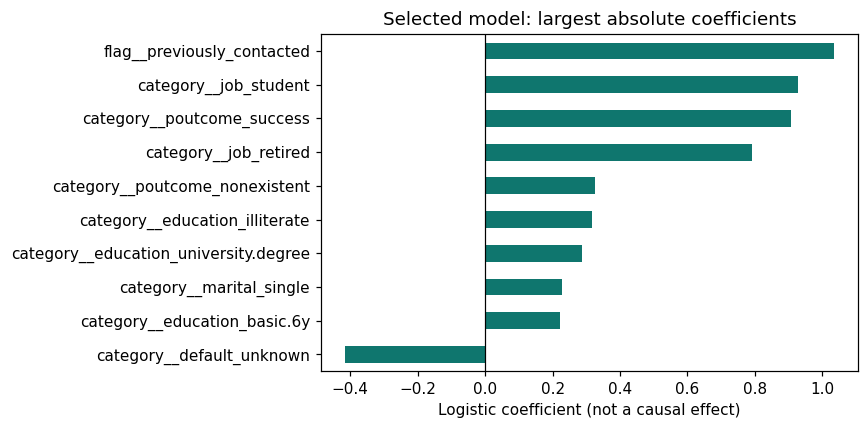

,Reference category
job,admin.
marital,divorced
education,basic.4y
default,no
housing,no
loan,no
poutcome,failure


,coefficient
category__default_unknown,-0.415
category__education_basic.6y,0.222
category__marital_single,0.229
category__education_university.degree,0.286
category__education_illiterate,0.317
category__poutcome_nonexistent,0.327
category__job_retired,0.790
category__poutcome_success,0.908
category__job_student,0.927
flag__previously_contacted,1.033


In [8]:
names = final_model.named_steps["prepare"].get_feature_names_out()
coefficients = pd.Series(final_model.named_steps["model"].coef_[0], index=names)
top_names = coefficients.abs().sort_values(ascending=False).head(10).index
top_coefficients = coefficients.loc[top_names].sort_values()
plt.figure(figsize=(8, 4))
top_coefficients.plot.barh(color="#0f766e")
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Logistic coefficient (not a causal effect)")
plt.title("Selected model: largest absolute coefficients")
plt.tight_layout()
plt.show()
encoder = final_model.named_steps["prepare"].named_transformers_["category"]
display(pd.Series({col: values[0] for col, values in zip(categorical, encoder.categories_)},
                  name="Reference category").to_frame())
display(top_coefficients.round(3).rename("coefficient").to_frame())

### 8. Business discussion and recommendation
The model flags **5,364/8,236 records (65.13%)**, capturing **1,975/2,539 subscribers (77.79%)**. It leaves 2,872 records unflagged but misses 564 subscribers; 3,389 flagged records did not subscribe. The flagged response rate is **36.82%**, versus **30.83%** overall. This is a historical prioritisation trade-off, not proof of saved calls or additional sales; rows are not verified distinct people.

Prior-contact history, student/retired job categories and prior success have positive model coefficients; unknown default information has a negative coefficient. Job comparisons use `admin.` and prior outcome uses `failure` as references. These are associations. Sparse categories and correlated history indicators make isolated coefficient claims unreliable.

**Recommendation: do not deploy automatically.** Modest validation discrimination, substantial period change, many false positives and missing contact costs weaken the business case. Class weighting also means model scores should not be treated as calibrated subscription probabilities.

Obtain recent data and verified planning-time snapshots, check contact eligibility and subgroup outcomes, and estimate the cost of wasted contacts versus missed subscriptions. Only then consider a controlled pilot against the current campaign policy. Monitor response, precision/recall and changing customer mix. Historical selection bias, absent IDs and data from 2008-2010 limit transfer to today's bank; no causal or profit claim is justified.

### 9. References and reproducibility
**Run:** keep this notebook beside `data/`, restart the kernel, and run all cells from the project directory. The first cell prints package versions. The split is deterministic; there is no sampling or random search. HTML is exported from executed outputs.

**AI assistance:** AI was used to assist with coding and explanations, as permitted by the tutor according to the author. The accompanying study guide explains the implementation for review.

Moro, S., Rita, P. and Cortez, P. (2014) *Bank Marketing* [Dataset]. UCI Machine Learning Repository. Available at: https://doi.org/10.24432/C5K306 (Accessed: 11 September 2026).

Mahdavi, M. (n.d.a) *Introduction to Machine Learning* [Lecture slides]. Gisma University of Applied Sciences, B104.

Mahdavi, M. (n.d.b) *Pre-Modeling Steps* [Lecture slides]. Gisma University of Applied Sciences, B104.

Mahdavi, M. (n.d.c) *Logistic Regression* [Lecture slides]. Gisma University of Applied Sciences, B104.

Mahdavi, M. (n.d.d) *K-Nearest Neighbors* [Lecture slides]. Gisma University of Applied Sciences, B104.

Mahdavi, M. (n.d.e) *Model Training* [Lecture slides]. Gisma University of Applied Sciences, B104. Page citations use PDF pages.

scikit-learn developers (n.d.a) *Common pitfalls and recommended practices*. Available at: https://scikit-learn.org/1.6/common_pitfalls.html (Accessed: 13 September 2026).

scikit-learn developers (n.d.b) *LogisticRegression*. Available at: https://scikit-learn.org/1.6/modules/generated/sklearn.linear_model.LogisticRegression.html (Accessed: 13 September 2026).

scikit-learn developers (n.d.c) *KNeighborsClassifier*. Available at: https://scikit-learn.org/1.6/modules/generated/sklearn.neighbors.KNeighborsClassifier.html (Accessed: 13 September 2026).

scikit-learn developers (n.d.d) *OneHotEncoder*. Available at: https://scikit-learn.org/1.6/modules/generated/sklearn.preprocessing.OneHotEncoder.html (Accessed: 13 September 2026).